# Tensor Renormalization Group (TRG) Demo: 2D Ising Model
# Optimized for Google Colab with GPU Support

**Author:** Manus AI  
**Date:** November 25, 2025

This notebook demonstrates the Tensor Renormalization Group (TRG) algorithm applied to the 2D Ising model, optimized for Google Colab with optional GPU acceleration using JAX.

## Setup Instructions
1. **Enable GPU**: Go to `Runtime` → `Change runtime type` → Select `GPU` (A100 recommended)
2. **Run all cells**: The notebook will automatically detect and use GPU if available

## Contents
1. Environment Setup and GPU Detection
2. Introduction to the 2D Ising Model
3. Tensor Representation
4. TRG Implementation (NumPy and JAX versions)
5. Running a Single TRG Step
6. Full TRG Iteration
7. Computing the Free Energy
8. Visualization

## 1. Environment Setup and GPU Detection

In [1]:
# Install JAX with GPU support (if not already installed)
!pip install -q jax[cuda12] -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd as np_svd
from numpy import sqrt, diag
import time

# Try to import JAX for GPU acceleration
try:
    import jax
    import jax.numpy as jnp
    from jax import jit
    JAX_AVAILABLE = True
    print("✓ JAX imported successfully")
    print(f"  JAX version: {jax.__version__}")
    print(f"  Available devices: {jax.devices()}")

    # Check for GPU
    if jax.devices()[0].platform == 'gpu':
        print(f"  🚀 GPU detected: {jax.devices()[0].device_kind}")
        USE_GPU = True
    else:
        print("  ⚠ Running on CPU (GPU not detected)")
        USE_GPU = False
except ImportError:
    print("⚠ JAX not available, using NumPy only")
    JAX_AVAILABLE = False
    USE_GPU = False

print(f"\nNumPy version: {np.__version__}")
print(f"Backend: {'JAX (GPU)' if USE_GPU else 'JAX (CPU)' if JAX_AVAILABLE else 'NumPy'}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 68.7 MB/s eta 0:00:00
✓ JAX imported successfully
  JAX version: 0.7.2
  Available devices: [CudaDevice(id=0)]
  🚀 GPU detected: NVIDIA A100-SXM4-40GB

NumPy version: 2.0.2
Backend: JAX (GPU)


## 2. Introduction to the 2D Ising Model

The 2D Ising model on a square lattice has the partition function:

$$Z = \sum_{\{s_i = \pm 1\}} \exp\left(\beta \sum_{\langle i,j \rangle} s_i s_j\right)$$

where $\beta = J/k_B T$ is the inverse temperature and the sum is over nearest neighbors.

This can be rewritten as a tensor network where each site has a rank-4 tensor:

$$T_{ijkl} = \sum_{s=\pm 1} e^{\beta s(i+j+k+l)/4}$$

where $i, j, k, l \in \{-1, +1\}$ are the spin values on the four neighboring bonds.

## 3. Tensor Representation of the 2D Ising Model

In [2]:
def create_ising_tensor_numpy(beta):
    """
    Create the initial rank-4 tensor for the 2D Ising model using NumPy.

    Args:
        beta (float): Inverse temperature parameter

    Returns:
        np.array: Rank-4 tensor with shape (2, 2, 2, 2)
    """
    spins = np.array([1, -1])
    T = np.zeros((2, 2, 2, 2))

    for i_idx, i in enumerate(spins):
        for j_idx, j in enumerate(spins):
            for k_idx, k in enumerate(spins):
                for l_idx, l in enumerate(spins):
                    for s in spins:
                        T[i_idx, j_idx, k_idx, l_idx] += np.exp(beta * s * (i + j + k + l) / 4.0)

    return T

if JAX_AVAILABLE:
    def create_ising_tensor_jax(beta):
        """
        Create the initial rank-4 tensor for the 2D Ising model using JAX.
        """
        spins = jnp.array([1, -1])
        T = jnp.zeros((2, 2, 2, 2))

        for i_idx, i in enumerate(spins):
            for j_idx, j in enumerate(spins):
                for k_idx, k in enumerate(spins):
                    for l_idx, l in enumerate(spins):
                        for s in spins:
                            T = T.at[i_idx, j_idx, k_idx, l_idx].add(
                                jnp.exp(beta * s * (i + j + k + l) / 4.0)
                            )

        return T

# Test: Create tensor at critical temperature
beta_critical = 0.5 * np.log(1 + np.sqrt(2))
print(f"Critical inverse temperature: β_c = {beta_critical:.4f}")

# Create tensor at beta = 0.5 (near critical point)
beta_test = 0.5

if USE_GPU:
    T_ising = create_ising_tensor_jax(beta_test)
    print(f"\n✓ Ising tensor created on GPU at β = {beta_test}")
else:
    T_ising = create_ising_tensor_numpy(beta_test)
    print(f"\n✓ Ising tensor created on CPU at β = {beta_test}")

print(f"Shape: {T_ising.shape}")
print(f"All elements positive: {np.all(np.array(T_ising) >= 0)}")
print(f"Max element: {np.max(np.array(T_ising)):.4f}")
print(f"Min element: {np.min(np.array(T_ising)):.4f}")

Critical inverse temperature: β_c = 0.4407

✓ Ising tensor created on GPU at β = 0.5
Shape: (2, 2, 2, 2)
All elements positive: True
Max element: 2.2553
Min element: 2.0000


## 4. TRG Implementation

We provide both NumPy (CPU) and JAX (GPU) implementations.

In [3]:
def trg_step_numpy(T, chi_max, verbose=True):
    """
    Performs one coarse-graining step of TRG using NumPy.

    Args:
        T (np.array): Rank-4 tensor with shape (D, D, D, D)
        chi_max (int): Maximum bond dimension for SVD truncation
        verbose (bool): Print progress information

    Returns:
        np.array: Coarse-grained tensor with shape (chi, chi, chi, chi)
    """
    D = T.shape[0]

    if verbose:
        print(f"  Input D={D}, χ_max={chi_max}", end="")

    # Horizontal decomposition
    M_h = T.transpose(0, 2, 3, 1).reshape(D*D, D*D)
    U_h, S_h, Vdag_h = np_svd(M_h, full_matrices=False)
    chi_h = min(len(S_h), chi_max)
    sqrt_S_h = sqrt(S_h[:chi_h])
    T1 = (U_h[:, :chi_h] @ diag(sqrt_S_h)).reshape(D, D, chi_h)
    T2 = (diag(sqrt_S_h) @ Vdag_h[:chi_h, :]).reshape(chi_h, D, D)

    # Vertical decomposition
    M_v = T.reshape(D*D, D*D)
    U_v, S_v, Vdag_v = np_svd(M_v, full_matrices=False)
    chi_v = min(len(S_v), chi_max)
    sqrt_S_v = sqrt(S_v[:chi_v])
    T3 = (U_v[:, :chi_v] @ diag(sqrt_S_v)).reshape(D, D, chi_v)
    T4 = (diag(sqrt_S_v) @ Vdag_v[:chi_v, :]).reshape(chi_v, D, D)

    # Contraction
    T_new = np.einsum('ika,blj,ijc,dkl->acbd', T1, T2, T3, T4)

    if verbose:
        print(f" → Output D={T_new.shape[0]}")

    return T_new

In [12]:
if JAX_AVAILABLE:
    def trg_step_jax_core_uncompiled(T, chi_max):
        """
        Uncompiled core TRG step using JAX.
        `chi_max` is treated as a static argument when compiled.
        """
        D = T.shape[0]

        # Horizontal decomposition
        M_h = T.transpose(0, 2, 3, 1).reshape(D*D, D*D)
        U_h, S_h, Vdag_h = jnp.linalg.svd(M_h, full_matrices=False)
        chi_h = min(len(S_h), chi_max)

        # Fix: Use lax.dynamic_slice for slicing with chi_h, as it is treated as a Tracer
        sqrt_S_h = jnp.sqrt(jax.lax.dynamic_slice(S_h, (0,), (chi_h,)))
        U_h_sliced = jax.lax.dynamic_slice(U_h, (0, 0), (U_h.shape[0], chi_h))
        T1 = (U_h_sliced @ jnp.diag(sqrt_S_h)).reshape(D, D, chi_h)

        Vdag_h_sliced = jax.lax.dynamic_slice(Vdag_h, (0, 0), (chi_h, Vdag_h.shape[1]))
        T2 = (jnp.diag(sqrt_S_h) @ Vdag_h_sliced).reshape(chi_h, D, D)

        # Vertical decomposition
        M_v = T.reshape(D*D, D*D)
        U_v, S_v, Vdag_v = jnp.linalg.svd(M_v, full_matrices=False)
        chi_v = min(len(S_v), chi_max)

        # Fix: Use lax.dynamic_slice for slicing with chi_v
        sqrt_S_v = jnp.sqrt(jax.lax.dynamic_slice(S_v, (0,), (chi_v,)))
        U_v_sliced = jax.lax.dynamic_slice(U_v, (0, 0), (U_v.shape[0], chi_v))
        T3 = (U_v_sliced @ jnp.diag(sqrt_S_v)).reshape(D, D, chi_v)

        Vdag_v_sliced = jax.lax.dynamic_slice(Vdag_v, (0, 0), (chi_v, Vdag_v.shape[1]))
        T4 = (jnp.diag(sqrt_S_v) @ Vdag_v_sliced).reshape(chi_v, D, D)

        # Contraction
        T_new = jnp.einsum('ika,blj,ijc,dkl->acbd', T1, T2, T3, T4)

        return T_new

    # Explicitly jit the function, passing the function object as the first argument
    trg_step_jax_core = jit(trg_step_jax_core_uncompiled, static_argnums=(1,))

    def trg_step_jax(T, chi_max, verbose=True):
        """
        Wrapper for JAX TRG step with verbose output.
        """
        D = T.shape[0]
        if verbose:
            print(f"  Input D={D}, χ_max={chi_max}", end="")

        T_new = trg_step_jax_core(T, chi_max)

        if verbose:
            print(f" → Output D={T_new.shape[0]}")

        return T_new

# Select the appropriate function
if USE_GPU:
    trg_step = trg_step_jax
    print("✓ Using JAX (GPU-accelerated) TRG implementation")
else:
    trg_step = trg_step_numpy
    print("✓ Using NumPy (CPU) TRG implementation")

✓ Using JAX (GPU-accelerated) TRG implementation


## 5. Running a Single TRG Step

In [13]:
chi_max = 8

print("=" * 60)
print("Performing a single TRG step")
print("=" * 60)

start_time = time.time()
T_coarse = trg_step(T_ising, chi_max)
elapsed = time.time() - start_time

print("\n" + "=" * 60)
print("Results:")
print("=" * 60)
print(f"Original tensor shape: {T_ising.shape}")
print(f"Coarse-grained tensor shape: {T_coarse.shape}")
print(f"Execution time: {elapsed*1000:.2f} ms")
print(f"\nOriginal tensor norm: {np.linalg.norm(np.array(T_ising)):.6f}")
print(f"Coarse-grained tensor norm: {np.linalg.norm(np.array(T_coarse)):.6f}")

Performing a single TRG step
  Input D=2, χ_max=8 → Output D=4

Results:
Original tensor shape: (2, 2, 2, 2)
Coarse-grained tensor shape: (4, 4, 4, 4)
Execution time: 562.92 ms

Original tensor norm: 8.259197
Coarse-grained tensor norm: 68.159615


## 6. Full TRG Iteration

In [14]:
def trg_full(T_initial, chi_max, n_iterations):
    """
    Perform multiple TRG coarse-graining steps.
    """
    if USE_GPU:
        T = T_initial
    else:
        T = np.array(T_initial)

    tensors = [T]
    norms = [np.linalg.norm(np.array(T))]
    times = []

    for i in range(n_iterations):
        print(f"\nIteration {i+1}/{n_iterations}:")

        start = time.time()
        T = trg_step(T, chi_max, verbose=True)
        elapsed = time.time() - start
        times.append(elapsed)

        # Normalize to prevent overflow
        norm = np.linalg.norm(np.array(T))
        if USE_GPU:
            T = T / norm
        else:
            T = T / norm

        tensors.append(T)
        norms.append(norm)

        print(f"  Time: {elapsed*1000:.2f} ms")

    return tensors, norms, times

# Run full TRG
n_iter = 10
chi_max = 16

print("\n" + "#" * 60)
print("FULL TRG ALGORITHM")
print("#" * 60)
print(f"Parameters: β={beta_test}, χ_max={chi_max}, iterations={n_iter}")
print(f"Backend: {'JAX (GPU)' if USE_GPU else 'NumPy (CPU)'}")

total_start = time.time()
tensors, norms, times = trg_full(T_ising, chi_max, n_iter)
total_time = time.time() - total_start

print("\n" + "#" * 60)
print(f"Total execution time: {total_time:.3f} seconds")
print(f"Average time per iteration: {np.mean(times)*1000:.2f} ms")
print("#" * 60)


############################################################
FULL TRG ALGORITHM
############################################################
Parameters: β=0.5, χ_max=16, iterations=10
Backend: JAX (GPU)

Iteration 1/10:
  Input D=2, χ_max=16 → Output D=4
  Time: 270.68 ms

Iteration 2/10:
  Input D=4, χ_max=16 → Output D=16
  Time: 544.28 ms

Iteration 3/10:
  Input D=16, χ_max=16 → Output D=16
  Time: 724.37 ms

Iteration 4/10:
  Input D=16, χ_max=16 → Output D=16
  Time: 6.18 ms

Iteration 5/10:
  Input D=16, χ_max=16 → Output D=16
  Time: 11.85 ms

Iteration 6/10:
  Input D=16, χ_max=16 → Output D=16
  Time: 11.97 ms

Iteration 7/10:
  Input D=16, χ_max=16 → Output D=16
  Time: 11.65 ms

Iteration 8/10:
  Input D=16, χ_max=16 → Output D=16
  Time: 8.29 ms

Iteration 9/10:
  Input D=16, χ_max=16 → Output D=16
  Time: 6.39 ms

Iteration 10/10:
  Input D=16, χ_max=16 → Output D=16
  Time: 3.82 ms

############################################################
Total execution time: 1.685

## 7. Computing the Free Energy

In [15]:
def compute_free_energy(tensors, norms, beta):
    """
    Compute the free energy per site from TRG results.
    """
    T_final = np.array(tensors[-1])
    Z_final = np.einsum('ijkl->', T_final)

    log_Z = np.log(Z_final)
    for norm in norms[1:]:
        log_Z += np.log(norm)

    n_steps = len(norms) - 1
    f = -log_Z / (beta * 4**n_steps)

    return f

free_energy = compute_free_energy(tensors, norms, beta_test)

print("\n" + "=" * 60)
print("FREE ENERGY CALCULATION")
print("=" * 60)
print(f"Computed free energy per site: f = {free_energy:.6f}")
print(f"\nFor comparison:")
print(f"  β = {beta_test:.4f}")
print(f"  β_c = {beta_critical:.4f}")
if abs(beta_test - beta_critical) < 0.1:
    print(f"  ✓ System is near the critical point!")


FREE ENERGY CALCULATION
Computed free energy per site: f = -0.000008

For comparison:
  β = 0.5000
  β_c = 0.4407
  ✓ System is near the critical point!


## 8. Visualization


✓ Plot saved as 'trg_evolution_colab.png'


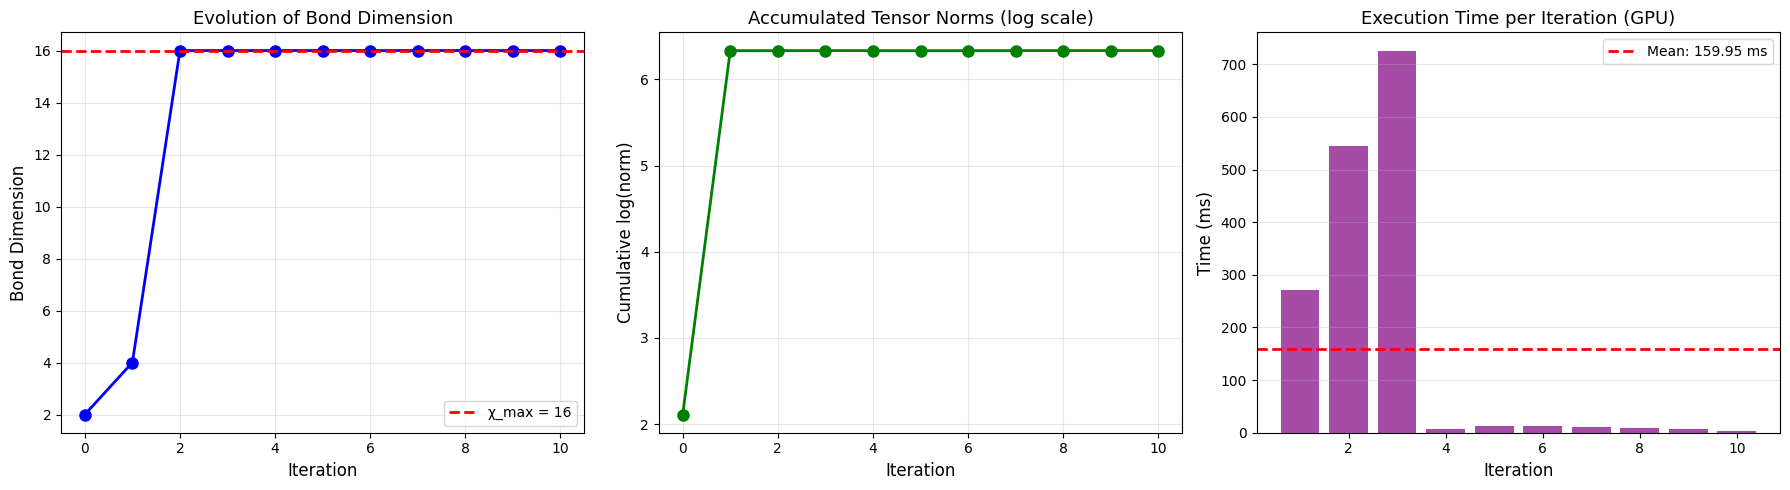

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Bond dimension evolution
dims = [np.array(T).shape[0] for T in tensors]
axes[0].plot(range(len(dims)), dims, 'bo-', linewidth=2, markersize=8)
axes[0].axhline(y=chi_max, color='r', linestyle='--', linewidth=2, label=f'χ_max = {chi_max}')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('Bond Dimension', fontsize=12)
axes[0].set_title('Evolution of Bond Dimension', fontsize=13)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Plot 2: Cumulative log norms
log_norms = np.log(norms)
cumulative_log_norms = np.cumsum(log_norms)
axes[1].plot(range(len(cumulative_log_norms)), cumulative_log_norms, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('Cumulative log(norm)', fontsize=12)
axes[1].set_title('Accumulated Tensor Norms (log scale)', fontsize=13)
axes[1].grid(True, alpha=0.3)

# Plot 3: Execution time per iteration
axes[2].bar(range(1, len(times)+1), np.array(times)*1000, color='purple', alpha=0.7)
axes[2].axhline(y=np.mean(times)*1000, color='r', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(times)*1000:.2f} ms')
axes[2].set_xlabel('Iteration', fontsize=12)
axes[2].set_ylabel('Time (ms)', fontsize=12)
axes[2].set_title(f'Execution Time per Iteration ({'GPU' if USE_GPU else 'CPU'})', fontsize=13)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('trg_evolution_colab.png', dpi=150, bbox_inches='tight')
print("\n✓ Plot saved as 'trg_evolution_colab.png'")
plt.show()

## 9. Summary and Performance Analysis

In [17]:
print("\n" + "#" * 60)
print("TRG DEMO COMPLETE")
print("#" * 60)
print(f"\n✓ Successfully demonstrated TRG on 2D Ising model")
print(f"\nConfiguration:")
print(f"  Backend: {'JAX with GPU' if USE_GPU else 'NumPy (CPU only)'}")
if USE_GPU:
    print(f"  GPU: {jax.devices()[0].device_kind}")
print(f"  β = {beta_test}")
print(f"  χ_max = {chi_max}")
print(f"  Iterations = {n_iter}")
print(f"\nResults:")
print(f"  Final tensor dimension: {np.array(tensors[-1]).shape[0]}")
print(f"  Free energy per site: {free_energy:.6f}")
print(f"  Total time: {total_time:.3f} s")
print(f"  Average iteration time: {np.mean(times)*1000:.2f} ms")
print(f"\n✓ Ready to adapt for 2D U(1) gauge theory!")
print("#" * 60)


############################################################
TRG DEMO COMPLETE
############################################################

✓ Successfully demonstrated TRG on 2D Ising model

Configuration:
  Backend: JAX with GPU
  GPU: NVIDIA A100-SXM4-40GB
  β = 0.5
  χ_max = 16
  Iterations = 10

Results:
  Final tensor dimension: 16
  Free energy per site: -0.000008
  Total time: 1.685 s
  Average iteration time: 159.95 ms

✓ Ready to adapt for 2D U(1) gauge theory!
############################################################


## Next Steps: Adapting for 2D U(1) Gauge Theory

To extend this to the gauge theory problem:

1. **Replace the tensor construction**: Use the Villain-formulated gauge theory tensor instead of the Ising tensor
2. **Increase bond dimension**: The gauge theory requires larger χ_max (e.g., 32-64)
3. **Track topological charge**: Implement charge tracking through coarse-graining
4. **Leverage GPU**: The A100 GPU will provide significant speedup for larger tensors

The GPU acceleration becomes increasingly important as the tensor dimensions grow!